<a href="https://colab.research.google.com/github/EyoGod/cnnrnn/blob/main/cnnrnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/12
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 30ms/step - accuracy: 0.7993 - loss: 0.5543 - val_accuracy: 0.8632 - val_loss: 0.3736
Epoch 2/12
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.8652 - loss: 0.3799 - val_accuracy: 0.8815 - val_loss: 0.3197
Epoch 3/12
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 32ms/step - accuracy: 0.8824 - loss: 0.3276 - val_accuracy: 0.8799 - val_loss: 0.3199
Epoch 4/12
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 74s 28ms/step - accuracy: 0.8921 - loss: 0.2956 - val_accuracy: 0.8878 - val_loss: 0.3053
Epoch 5/12
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9021 - loss: 0.2678 - val_accuracy: 0.9016 - val_loss: 0.2734
Epoch 6/12
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9091 - loss: 0.2496 - val_accuracy: 0.9041 - val_loss: 0.2650
Epoch 7/12
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.9125 - loss: 0.2363 - val_accuracy: 0.9017 - val_loss: 0.2693
Epoch 8/12
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.9182 -

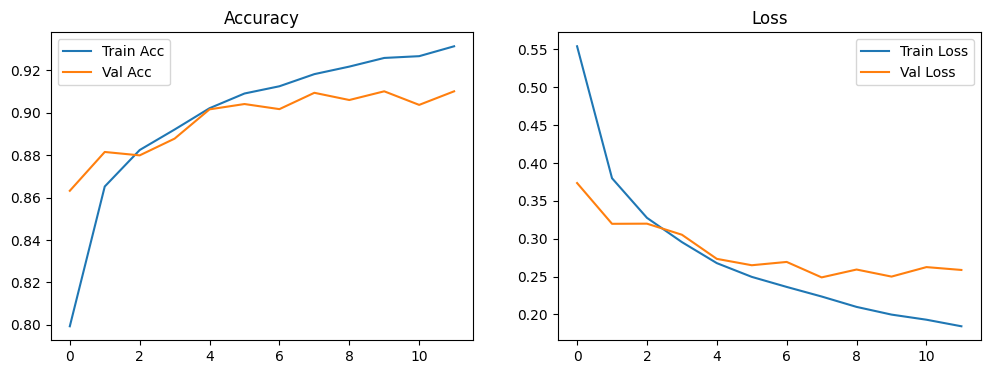

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


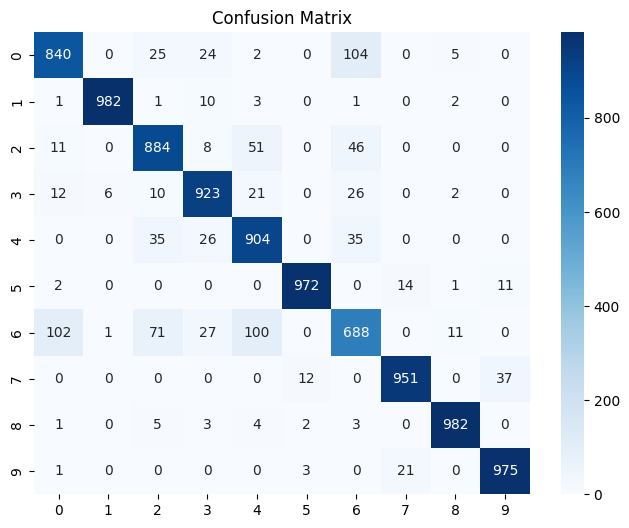

              precision    recall  f1-score   support

 T-shirt/top       0.87      0.84      0.85      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.86      0.88      0.87      1000
       Dress       0.90      0.92      0.91      1000
        Coat       0.83      0.90      0.87      1000
      Sandal       0.98      0.97      0.98      1000
       Shirt       0.76      0.69      0.72      1000
     Sneaker       0.96      0.95      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.95      0.97      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [ ]:
# CNN for Fashion-MNIST Classification
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# 1. Load dataset
(x_train, y_train), (x_test, y_test) = datasets.fashion_mnist.load_data()

# 2. Preprocess
x_train = x_train / 255.0
x_test = x_test / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# 3. Build CNN
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# 4. Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 5. Train
history = model.fit(x_train, y_train, epochs=12,
                    validation_data=(x_test, y_test))

# 6. Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")

# 7. Plot curves
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title("Loss")
plt.show()

# 8. Confusion matrix
y_pred = np.argmax(model.predict(x_test), axis=-1)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# 9. Classification report
print(classification_report(y_test, y_pred, target_names=[
    'T-shirt/top','Trouser','Pullover','Dress','Coat',
    'Sandal','Shirt','Sneaker','Bag','Ankle boot'
]))

/tmp/ipykernel_2601/4104702635.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2015-01-01", end="2023-12-31")
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.5143 - loss: 0.6935 - val_accuracy: 0.5163 - val_loss: 0.6948
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5219 - loss: 0.6928 - val_accuracy: 0.5163 - val_loss: 0.6924
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5156 - loss: 0.6937 - val_accuracy: 0.5163 - val_loss: 0.6926
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5251 - loss: 0.6940 - val_accuracy: 0.5163 - val_loss: 0.6925
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5321 - loss: 0.6931 - val_accuracy: 0.5163 - val_loss: 0.6921
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5308 - loss: 0.6931 - val_accuracy: 0.5163 - val_loss: 0.6928
Epoch 7/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5302 - loss: 0.6910 - val_accuracy: 0.5163 - val_loss: 0.6921
Epoch 8/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5296 - loss: 0.6927 - val_accuracy: 0.5163 - v

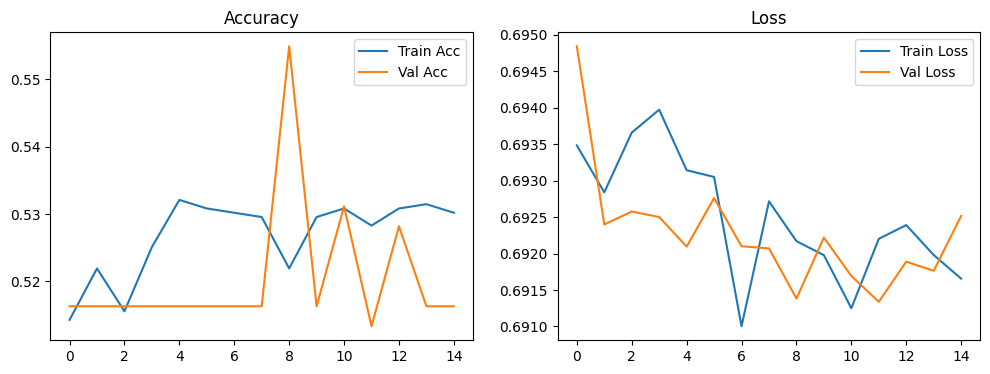

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


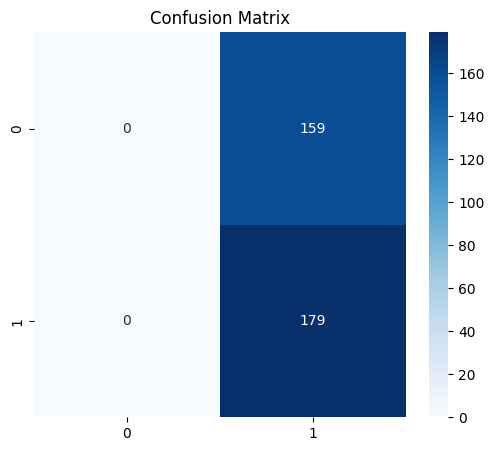

              precision    recall  f1-score   support

        Down       0.00      0.00      0.00       159
          Up       0.53      1.00      0.69       179

    accuracy                           0.53       338
   macro avg       0.26      0.50      0.35       338
weighted avg       0.28      0.53      0.37       338

Baseline accuracy (always up): 0.5296


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# LSTM for Stock Trend Forecasting
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Download stock data (Apple as example)
data = yf.download("AAPL", start="2015-01-01", end="2023-12-31")
closing_prices = data['Close'].values

# 2. Preprocess
sequence_length = 15
X, y = [], []
for i in range(len(closing_prices) - sequence_length - 1):
    seq = closing_prices[i:i+sequence_length]
    label = 1 if closing_prices[i+sequence_length] > closing_prices[i+sequence_length-1] else 0
    X.append(seq)
    y.append(label)

X = np.array(X)
y = np.array(y)

# Normalize
X = (X - X.mean()) / X.std()
X = X.reshape(X.shape[0], X.shape[1], 1)

# Train/val/test split
train_size = int(0.7 * len(X))
val_size = int(0.15 * len(X))
X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
X_test, y_test = X[train_size+val_size:], y[train_size+val_size:]

# 3. Build LSTM
model = models.Sequential([
    layers.LSTM(64, return_sequences=True, input_shape=(sequence_length,1)),
    layers.Dropout(0.3),
    layers.LSTM(32),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

# 4. Compile
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 5. Train
history = model.fit(X_train, y_train, epochs=15,
                    validation_data=(X_val, y_val))

# 6. Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")

# 7. Plot curves
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title("Loss")
plt.show()

# 8. Confusion matrix
y_pred = (model.predict(X_test) > 0.5).astype("int32")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# 9. Classification report
print(classification_report(y_test, y_pred, target_names=['Down','Up']))

# 10. Baseline comparison
baseline_acc = np.mean(y_test == 1)
print(f"Baseline accuracy (always up): {baseline_acc:.4f}")
